In [2]:
from jax.numpy import size
import numpy as np
from numpyro import distributions as dist
import numpyro
import polars as pl
import jax.numpy as jnp
from jax import random
import jax
from pathlib import Path
from sklearn.model_selection import train_test_split
import datetime as dt
from matplotlib import pyplot as plt
import xarray as xr

import arviz as az

numpyro.set_host_device_count(4)

data_dir = Path("./data")
df = (
    pl.read_csv(data_dir / "cleaned_games.csv")
    .with_columns(pl.col("Datetime").str.strptime(pl.Datetime).alias("Datetime"))
    .filter(
        pl.col("Datetime") >= dt.datetime(2025, 10, 1),
        pl.col("Arizona Coyotes") == 0,
    )
    .drop("Arizona Coyotes")
)

# current season games only

teams = (
    pl.read_csv(data_dir / "teams.txt", has_header=False)
    .filter(pl.col("column_1") != "Arizona Coyotes")
    .to_series()
    .to_list()
)


day_of_season = (df["Datetime"] - df["Datetime"].min()).dt.total_days().to_jax()
day_of_season = day_of_season - day_of_season.mean()
team_matchups = df[teams].to_jax()
home_wins = df["home_win"].to_jax()
goal_diffs = df["Goal_Diff"].to_jax()
home_goals = df["Home_G"].to_jax()
away_goals = df["Away_G"].to_jax()

train_shape = int(0.8 * len(df))

train_x, test_x, train_y, test_y, train_goal_diff, test_goal_diff, train_home_goals, test_home_goals, train_away_goals, test_away_goals = (
    team_matchups[:train_shape],
    team_matchups[train_shape:],
    home_wins[:train_shape],
    home_wins[train_shape:],
    goal_diffs[:train_shape],
    goal_diffs[train_shape:],
    home_goals[:train_shape],
    home_goals[train_shape:],
    away_goals[:train_shape],
    away_goals[train_shape:],
)
dates_train, dates_test = day_of_season[:train_shape], day_of_season[train_shape:]


In [3]:

def log_bessel_fn(x, n, max_terms=30):
    def log_term(k):
        return (
            (2*k + n) * jnp.log(x/2) - jax.scipy.special.gammaln(k + n + 1) - jax.scipy.special.gammaln(k + 1)
        )

    bessel_approx = jax.scipy.special.logsumexp(jax.vmap(log_term)(jnp.arange(max_terms)), axis=0)
    return bessel_approx

class NonZeroSkellam(dist.Distribution):
    arg_constraints = {"mu1": dist.constraints.positive, "mu2": dist.constraints.positive}
    support = dist.constraints.integer_interval(-jnp.inf, jnp.inf)

    def __init__(self, mu1, mu2, validate_args=None):
        self.mu1 = mu1
        self.mu2 = mu2
        super().__init__(batch_shape=jnp.shape(mu1), validate_args=validate_args)

    def _raw_log_pmf(self, k):
        log_pmf = (
            - (self.mu1 + self.mu2) + k * jnp.log(self.mu1 / self.mu2) / 2 + log_bessel_fn(2 * jnp.sqrt(self.mu1 * self.mu2), jnp.abs(k))
        )
        return log_pmf 

    def log_prob(self, k):
        log_zero_prob = self._raw_log_pmf(0)
        log_pmf_k = self._raw_log_pmf(k)
        log_nonzero_prob = jnp.log1p(-jnp.exp(log_zero_prob))

        return jnp.where(k == 0, -jnp.inf, log_pmf_k - log_nonzero_prob)

    def sample(self, key, sample_shape=()):

        def condn_fn(state):
            _, samples = state
            return jnp.any(samples == 0)

        def _run_samples(key):
            k1, k2 = jax.random.split(key, 2)
            return dist.Poisson(self.mu1).sample(k1, sample_shape) - dist.Poisson(self.mu2).sample(k2, sample_shape)

        key1, key2 = random.split(key)
        initial_samples = _run_samples(key1)

        def sample_fn(state):
            key, samples = state
            new_key, subkey = random.split(key)
            candidates = _run_samples(new_key)
            return subkey, jnp.where(samples == 0, candidates, samples)

        return jax.lax.while_loop(condn_fn, sample_fn, (key2, initial_samples))[1]


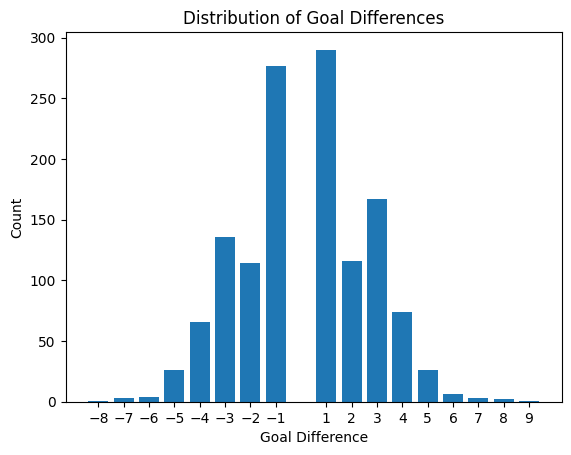

In [4]:
vals, counts = jnp.unique_counts(goal_diffs)
fig, ax = plt.subplots()
ax.bar(vals, counts)
ax.set_xlabel("Goal Difference")
ax.set_ylabel("Count")
ax.set_xticks(vals)
ax.set_title("Distribution of Goal Differences")
plt.show()

In [ ]:
@numpyro.handlers.reparam(config={"team_home_advantage": numpyro.infer.reparam.LocScaleReparam()})
def model(matchups, home_g=None, away_g=None):
    sigma_offense = numpyro.sample("sigma_offense", dist.InverseGamma(1, 1))
    sigma_defense = numpyro.sample("sigma_defense", dist.InverseGamma(1, 1))
    sigma_home_team = numpyro.sample("sigma_home_team", dist.InverseGamma(1, 1))

    home_advantage = numpyro.sample("home_advantage", dist.Normal(0, 0.5))
    # Non-centered: sample on unit scale, multiply by sigma outside
    with numpyro.plate("teams", size=matchups.shape[1]):
        offense_raw = numpyro.sample("offense_raw", dist.Normal(0, 1))
        defense_raw = numpyro.sample("defense_raw", dist.Normal(0, 1))
        team_home_advantage = numpyro.sample("team_home_advantage", dist.Normal(home_advantage, sigma_home_team))

    # Scale + sum-to-zero: kills the add-c-to-both degeneracy
    log_offense = numpyro.deterministic("log_offense", sigma_offense * (offense_raw - offense_raw.mean()))
    log_defense = numpyro.deterministic("log_defense", sigma_defense * (defense_raw - defense_raw.mean()))
    numpyro.deterministic("offense_goals", jnp.exp(log_offense))
    numpyro.deterministic("defense_goals", jnp.exp(log_defense))

    home_team_idx = jnp.argmax(matchups, axis=1)
    away_team_idx = jnp.argmin(matchups, axis=1)

    lambda_home = jnp.exp(log_offense[home_team_idx] - log_defense[away_team_idx] + team_home_advantage[home_team_idx])
    lambda_away = jnp.exp(log_offense[away_team_idx] - log_defense[home_team_idx])

    with numpyro.plate("obs", size=matchups.shape[0]):
        home_g = numpyro.sample("home_g", dist.Poisson(lambda_home), obs=home_g)
        away_g = numpyro.sample("away_g", dist.Poisson(lambda_away), obs=away_g)



In [83]:
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(
    kernel,
    num_warmup=2000,
    num_samples=1000,
    num_chains=4,
)

mcmc.run(random.key(90981238), matchups=train_x, home_g=train_home_goals, away_g=train_away_goals)

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/3000 [00:01<?, ?it/s]


In [84]:
trace = az.from_numpyro(
    mcmc,
    coords={"team": teams},
    dims={
        "offense_goals": ["team"],
        "defense_goals": ["team"],
        "team_home_advantage": ["team"],
    },
)

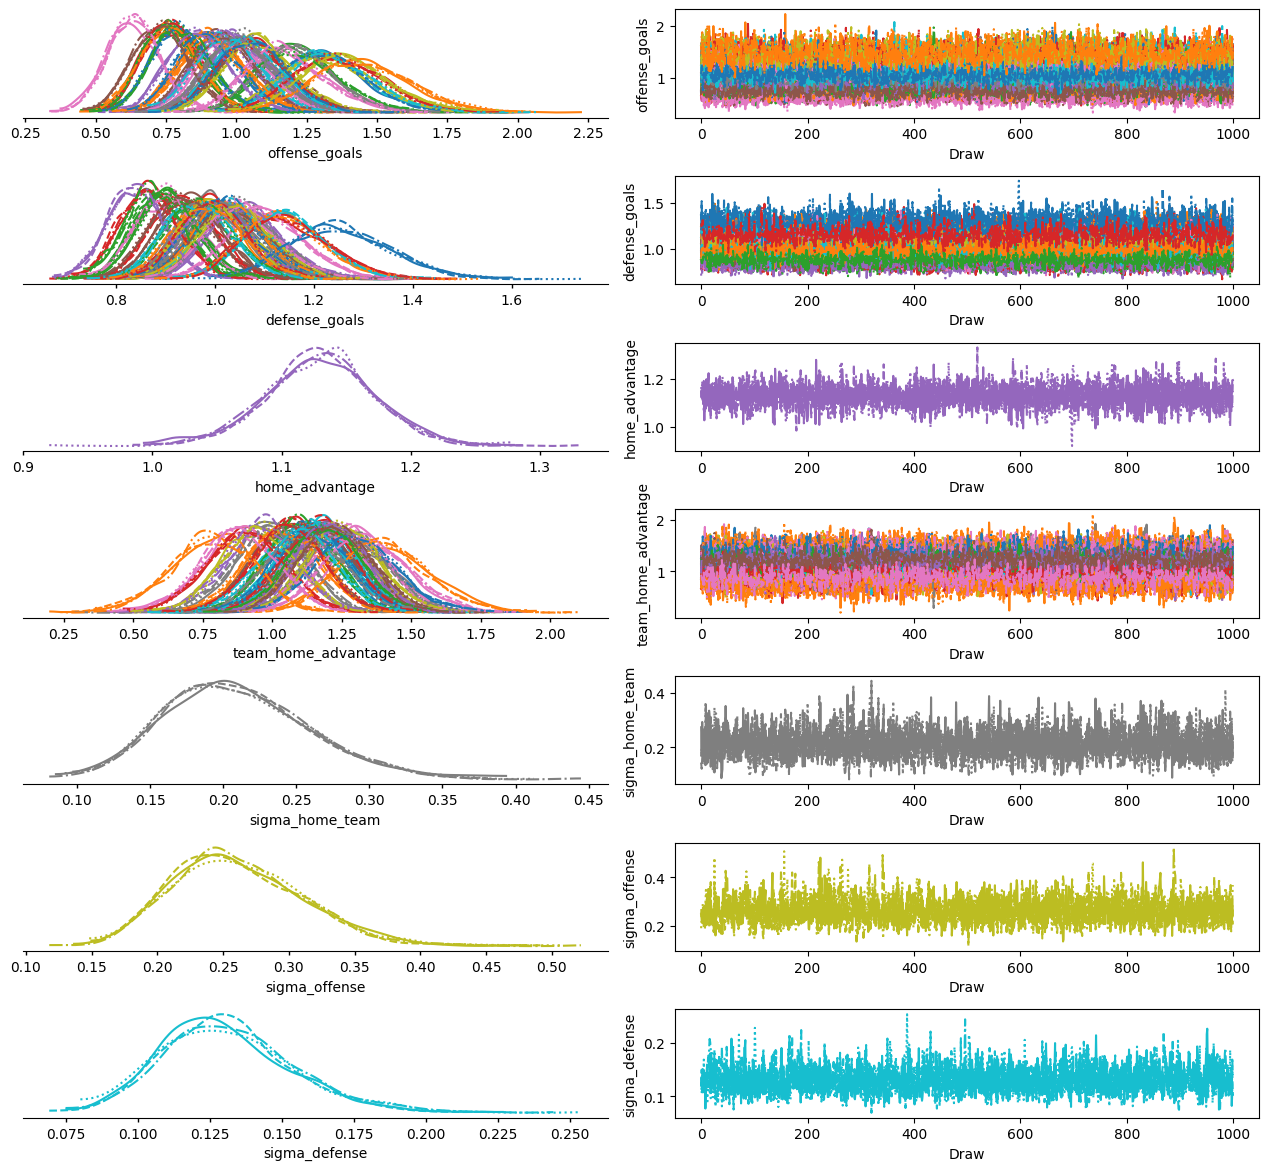

In [88]:
az.plot_trace_dist(trace, var_names=["offense_goals", "defense_goals", "home_advantage", "team_home_advantage", "sigma_home_team", "sigma_offense", "sigma_defense"])
plt.tight_layout()

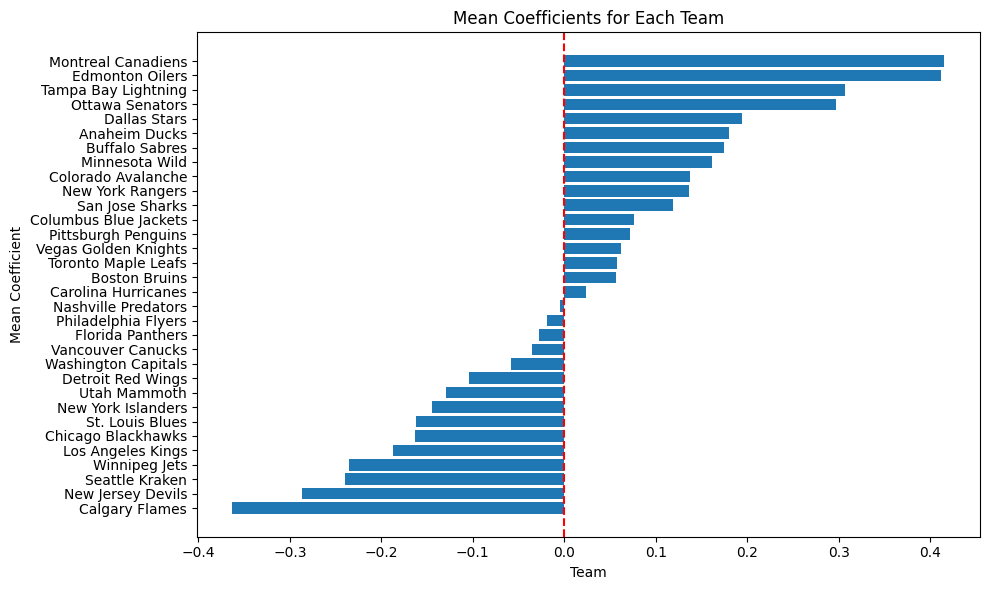

In [90]:
ranked = (trace.posterior["offense_goals"] - trace.posterior["defense_goals"]).mean(dim=["chain", "draw"])
ranked = ranked.sortby(ranked)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ranked.team.values, ranked.values)
ax.set_title("Mean Coefficients for Each Team")
ax.set_xlabel("Team")
ax.set_ylabel("Mean Coefficient")
ax.axvline(0, color="red", linestyle="dashed")
plt.tight_layout()


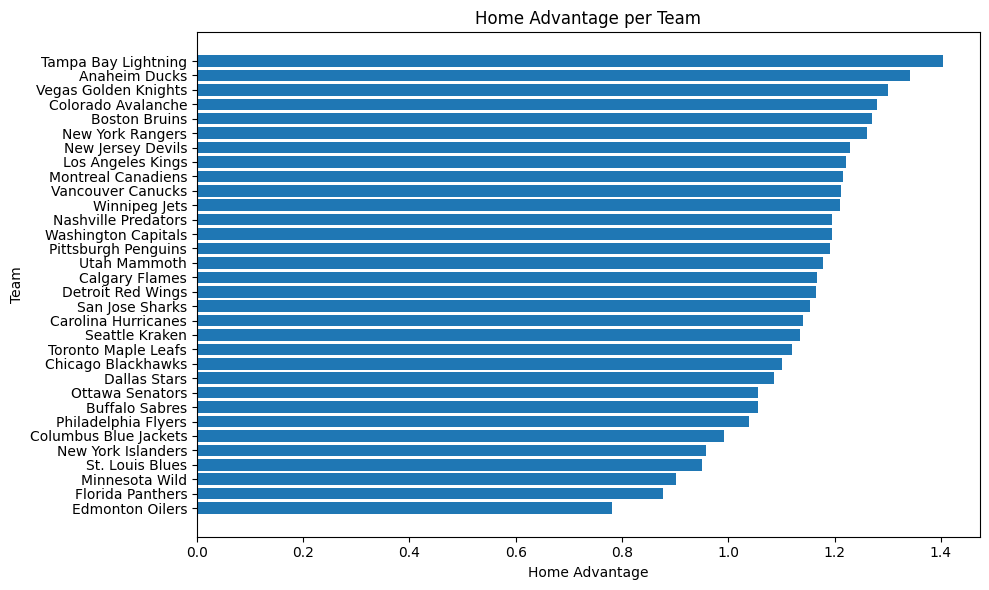

In [97]:
fig, ax = plt.subplots(figsize=(10, 6))
# home advantage per team
home_advantage = trace.posterior["team_home_advantage"].mean(dim=["chain", "draw"])
home_advantage = home_advantage.sortby(home_advantage)
ax.barh(teams, home_advantage.values)
ax.set_title("Home Advantage per Team")
ax.set_xlabel("Home Advantage")
ax.set_ylabel("Team")
plt.tight_layout()

In [ ]:
from numpyro.infer import Predictive

predict = Predictive(model, mcmc.get_samples())

pred_key = random.key(206817)
preds = predict(pred_key, test_x)

Mean Accuracy: 0.537


Text(0, 0.5, 'Frequency')

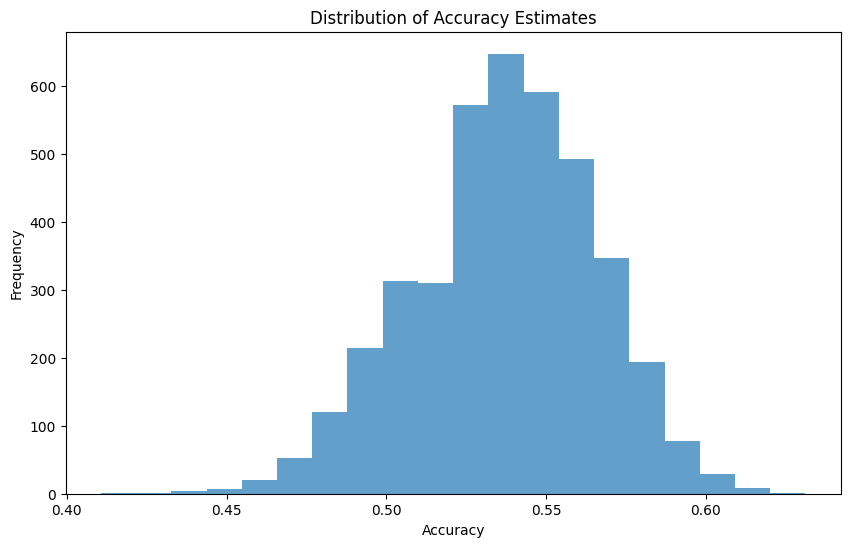

In [40]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)


accuracy_estimates = jax.vmap(accuracy_score, (None, 0))(test_y, preds["probs"] > 0.5)
print(f"Mean Accuracy: {accuracy_estimates.mean():.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(accuracy_estimates, bins=20, alpha=0.7)
ax.set_title("Distribution of Accuracy Estimates")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Frequency")


In [42]:
def generate_matchup(home_team, away_team, teams=teams):
    home_idx, away_idx = teams.index(home_team), teams.index(away_team)
    input_idx = jnp.zeros(len(teams))
    input_idx = input_idx.at[home_idx].set(1)
    input_idx = input_idx.at[away_idx].set(-1)
    return input_idx


def construct_transition_matrix(p, game_states):
    max_games = np.max([w for w in game_states])
    transition_matrix = jnp.zeros((len(game_states), len(game_states)))
    for i, state in enumerate(game_states):
        if max_games in state:
            # terminal state, no transitions
            transition_matrix = transition_matrix.at[i, game_states.index(state)].set(1)
        else:
            w1, l1 = (state[0] + 1, state[1]), (state[0], state[1] + 1)
            transition_matrix = transition_matrix.at[i, game_states.index(w1)].set(p)
            transition_matrix = transition_matrix.at[i, game_states.index(l1)].set(
                1 - p
            )

    return transition_matrix


def simulate_game_series(home_mat, away_mat, game_states):
    """
    Simulate a 2-2-1-1-1 series
    """
    outcome_mat = (
        home_mat @ home_mat @ away_mat @ away_mat @ home_mat @ away_mat @ home_mat
    )

    # you have to start at (0, 0)
    return outcome_mat[0, :]


def run_team_matchup(rng_key, matchup, game_states):
    """
    We start with "home team" arbitrarily as the strongest team, but they get flipped at later times. We adjust their probabilities accordingly.
    """
    # prob of home victory
    p_home = predict(rng_key, matchup)["probs"].squeeze()
    p_away = predict(rng_key, -matchup)["probs"].squeeze()

    game_labels = [f"{w}-{l}" for w, l in game_states]

    home_mat = jax.vmap(construct_transition_matrix, in_axes=(0, None))(
        p_home, game_states
    )
    away_mat = jax.vmap(construct_transition_matrix, in_axes=(0, None))(
        1 - p_away, game_states
    )

    simulated_series = jax.vmap(simulate_game_series, in_axes=(0, 0, None))(
        home_mat, away_mat, game_states
    )
    out_series = xr.DataArray(
        simulated_series,
        dims=["sample", "game_state"],
        coords={"game_state": game_labels},
    )
    out_series = out_series.sel(
        game_state=["4-0", "4-1", "4-2", "4-3", "3-4", "2-4", "1-4", "0-4"]
    )

    return out_series


In [43]:
key1, key2 = jax.random.split(random.key(2098910), 2)
matchup = generate_matchup("Philadelphia Flyers", "New York Rangers").reshape(1, -1)

home_probs = predict(key1, matchup)["probs"]
away_probs = predict(key2, -matchup)["probs"]

fig, ax = plt.subplots()
ax.hist(home_probs, bins=30)
ax.hist(away_probs, bins=30, alpha=0.5)
ax.set_title("Posterior Distribution of Home Win Probability")
ax.set_xlabel("Probability of Home Win")
ax.set_ylabel("Frequency")
ax.vlines(
    0.5, 0, ax.get_ylim()[1], colors="red", linestyles="dashed", label="50% Threshold"
)

TypeError: model() missing 1 required positional argument: 'game_dates'

In [ ]:
teamA = "Tampa Bay Lightning"
teamB = "Montreal Canadiens"

key = random.key(20250607)

game_states = [(w, l) for w in range(5) for l in range(5) if w + l <= 7]
matchup = generate_matchup(teamA, teamB).reshape(1, -1)


matchup_results = run_team_matchup(key, matchup, game_states=game_states)


# game_outcomes = xr.DataArray(series_outcome, coords={"sim": range(series_outcome.shape[0]), "from_state": game_labels, "to_state": game_labels}, dims=["sim", "from_state", "to_state"])
a_to_states = ["4-0", "4-1", "4-2", "4-3"]
b_to_states = ["3-4", "2-4", "1-4", "0-4"]

team_A_win_probs = matchup_results.sel(game_state=a_to_states).mean(dim="sample")
team_B_win_probs = matchup_results.sel(game_state=b_to_states).mean(dim="sample")


print(f"Probability {teamA} win series: {team_A_win_probs.sum():.3f}")
print("-----------------------------------\n")
print("Series Outcome Probabilities:\n")
for p, state in zip(team_A_win_probs.values, team_A_win_probs.coords["game_state"]):
    print(f"P({teamA}:{state.item()}) = {p:.3f}")

print("\n")

print(f"Probability {teamB} win series: {team_B_win_probs.sum():.3f}")
print("-----------------------------------\n")
for p, state in zip(team_B_win_probs.values, team_B_win_probs.coords["game_state"]):
    print(f"P({teamB}:{state.item()}) = {p:.3f}")


Probability Tampa Bay Lightning win series: 0.540
-----------------------------------

Series Outcome Probabilities:

P(Tampa Bay Lightning:4-0) = 0.076
P(Tampa Bay Lightning:4-1) = 0.146
P(Tampa Bay Lightning:4-2) = 0.157
P(Tampa Bay Lightning:4-3) = 0.160


Probability Montreal Canadiens win series: 0.460
-----------------------------------

P(Montreal Canadiens:3-4) = 0.138
P(Montreal Canadiens:2-4) = 0.150
P(Montreal Canadiens:1-4) = 0.112
P(Montreal Canadiens:0-4) = 0.060
